<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/SPI3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Author: Kumar Puran Tripathy (PhD, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                       ARIMA TIME SERIES ANALYSIS                            ║
# ║     Date-based Split (Train: 1901–1989 | Test: 1990–2018)                    ║
# ║         Original Series | ACF/PACF | (Next: Differencing & ARIMA)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install statsmodels openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch


from statsmodels.tsa.stattools   import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})

AMBER   = '#f59e0b'
GREEN   = '#34d399'
BLUE    = '#60a5fa'
ROSE    = '#f87171'
PURPLE  = '#a78bfa'
SLATE   = '#94a3b8'




Saving Climate division 1.xlsx to Climate division 1.xlsx


  SECTION 1: LOAD DATA + DATE-BASED TRAIN/TEST SPLIT


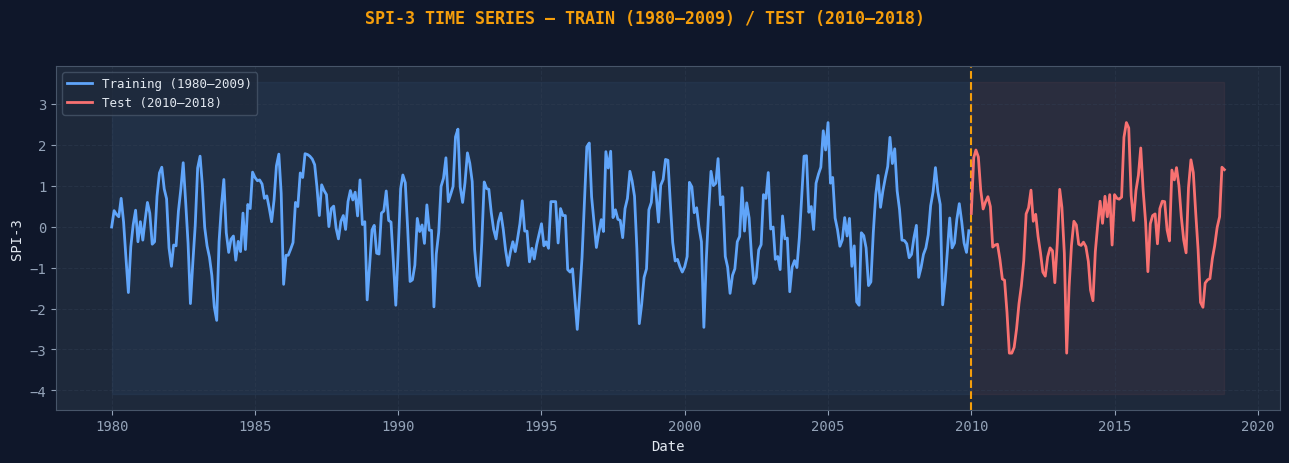

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA + DATE-BASED TRAIN/TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  SECTION 1: LOAD DATA + DATE-BASED TRAIN/TEST SPLIT")
print("=" * 70)

# --- Read Excel (robust header fix) ---
# If your Excel has headers in the first row, header=0 should work.
# But if pandas still shows "Unnamed: ..." then the header row is inside the data.
df_raw = pd.read_excel('Climate division 1.xlsx', header=0)

# If columns look like Unnamed: 0, Unnamed: 1 ... then fix using first data row
if any(str(c).startswith("Unnamed") for c in df_raw.columns):
    df_raw.columns = df_raw.iloc[0]
    df_raw = df_raw.drop(0).reset_index(drop=True)

df = df_raw.copy()



# --- Parse YearMonth into datetime ---
df['YearMonth'] = df['YearMonth'].astype(str).str.strip()
df['Year']  = df['YearMonth'].str[:4].astype(int)
df['Month'] = df['YearMonth'].str[4:].astype(int)
df['Date']  = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').set_index('Date')

# --- Replace common missing-value codes with NaN (important!) ---
# In your data: -99.99 (and sometimes -9999) appear as missing.
missing_codes = [-99.99, -9999, -999.9, -99.9]
df = df.replace(missing_codes, np.nan)


y = df['SP03'].astype(float)

# --- Train/Test split by date ---
train = y.loc['1980-01-01':'2009-12-01'].copy()
test  = y.loc['2010-01-01':].copy()

# --- Drop missing values at the ends (ARIMA cannot handle NaNs) ---
train = train.dropna()
test  = test.dropna()




# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1A — PLOT RAW SERIES WITH TRAIN/TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('SPI-3 TIME SERIES — TRAIN (1980–2009) / TEST (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

ax.plot(train.index, train.values, color=BLUE, lw=2, label='Training (1980–2009)', zorder=3)
ax.plot(test.index,  test.values,  color=ROSE, lw=2, label='Test (2010–2018)', zorder=3)

split_date = pd.to_datetime('2010-01-01')
ax.axvline(split_date, color=AMBER, lw=1.5, ls='--', zorder=2)

# Shaded regions (subtle)
ymin = min(train.min(), test.min()) - 1
ymax = max(train.max(), test.max()) + 1
ax.fill_betweenx([ymin, ymax], train.index.min(), split_date,
                 alpha=0.06, color=BLUE)
ax.fill_betweenx([ymin, ymax], split_date, test.index.max(),
                 alpha=0.06, color=ROSE)

ax.set_xlabel('Date')
ax.set_ylabel('SPI-3')
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
# plt.savefig('01_train_test_split_pdsi.png', dpi=150, bbox_inches='tight',
#             facecolor='#0f172a')
plt.show()




  SECTION 2: ORIGINAL SERIES + ACF & PACF (Training Set)


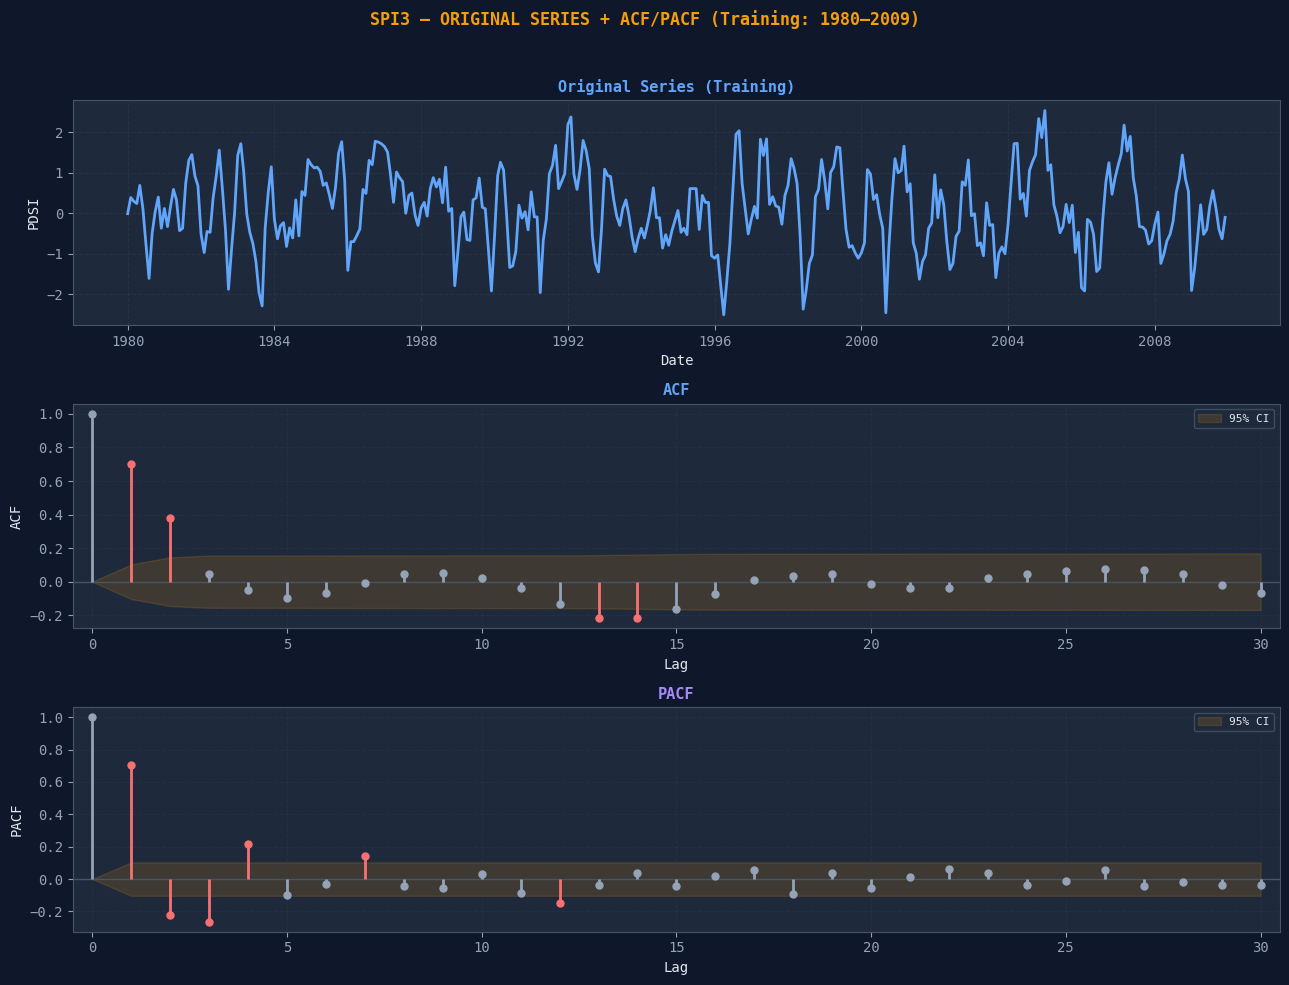

  ✓ Saved: 02_spi3_series_acf_pacf_train.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ORIGINAL SERIES + ACF/PACF (TRAINING DATA) IN ONE 3×1 PANEL
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ORIGINAL SERIES + ACF & PACF (Training Set)")
print("=" * 70)

def plot_series_acf_pacf_3x1(series, title, filename, nlags=40):
    series = series.dropna()

    # Compute ACF/PACF with confidence intervals for custom styling
    acf_vals, acf_ci   = acf(series, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold', y=0.98)

    # ── (1) Time series plot ────────────────────────────────────────────────
    axes[0].plot(series.index, series.values, color=BLUE, lw=2)
    axes[0].set_title('Original Series (Training)', color=BLUE, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('PDSI')
    axes[0].grid(True, alpha=0.4)

    # Helper: stem plot with CI shading (matches your style)
    def styled_corr_plot(ax, vals, ci, label, title_color):
        ci_lower = ci[:, 0] - vals
        ci_upper = ci[:, 1] - vals

        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)

        for lag in lags[1:]:
            # mark significant lags in ROSE
            c = ROSE if (vals[lag] < ci_lower[lag]) or (vals[lag] > ci_upper[lag]) else SLATE
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)

        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)

        ax.set_xlim(-0.5, nlags + 0.5)
        ax.set_xlabel('Lag')
        ax.set_ylabel(label)
        ax.set_title(label, color=title_color, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    # ── (2) ACF ─────────────────────────────────────────────────────────────
    styled_corr_plot(axes[1], acf_vals, acf_ci, 'ACF', BLUE)

    # ── (3) PACF ────────────────────────────────────────────────────────────
    styled_corr_plot(axes[2], pacf_vals, pacf_ci, 'PACF', PURPLE)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print(f"  ✓ Saved: {filename}")

plot_series_acf_pacf_3x1(
    train,
    'SPI3 — ORIGINAL SERIES + ACF/PACF (Training: 1980–2009)',
    '02_spi3_series_acf_pacf_train.png',
    nlags=30
)

## SPI-3 (Training) — What the plots say

- ACF: big spikes at lags **1–2**, then **dies out fast** (no slow decay).
- PACF: strongest spike at **lag 1**, smaller spikes up to **~lag 4**.
- Series oscillates around ~0 with stable variance.

**Conclusion: NO differencing needed (d = 0).**  
So we fit **ARIMA(p,0,q)**.

Candidate logic:
- AR part suggested by PACF (p ≈ 1–4)
- MA part suggested by ACF (q ≈ 1–2)

We’ll compare candidate models using **AIC/BIC** and pick the best (lower is better).


  SECTION 4: SPI-3 CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON

  Model                 AIC        BIC       HQIC     LogLik           σ²
  --------------------------------------------------------------
  ARIMA(1, 0, 0)    753.881    765.539    758.517   -373.941       0.4666
  ARIMA(2, 0, 0)    738.119    753.664    744.300   -365.060       0.4440
  ARIMA(3, 0, 0)    714.596    734.027    722.322   -352.298       0.4134
  ARIMA(4, 0, 0)    699.362    722.678    708.633   -343.681       0.3939
  ARIMA(1, 0, 1)    746.435    761.979    752.615   -369.217       0.4545
  ARIMA(2, 0, 1)    730.830    750.260    738.556   -360.415       0.4327
  ARIMA(1, 0, 2)    685.036    704.466    692.762   -337.518       0.3805
  ARIMA(2, 0, 2)    686.915    710.232    696.186   -337.458       0.3804

  Best model by AIC: ARIMA(1, 0, 2)


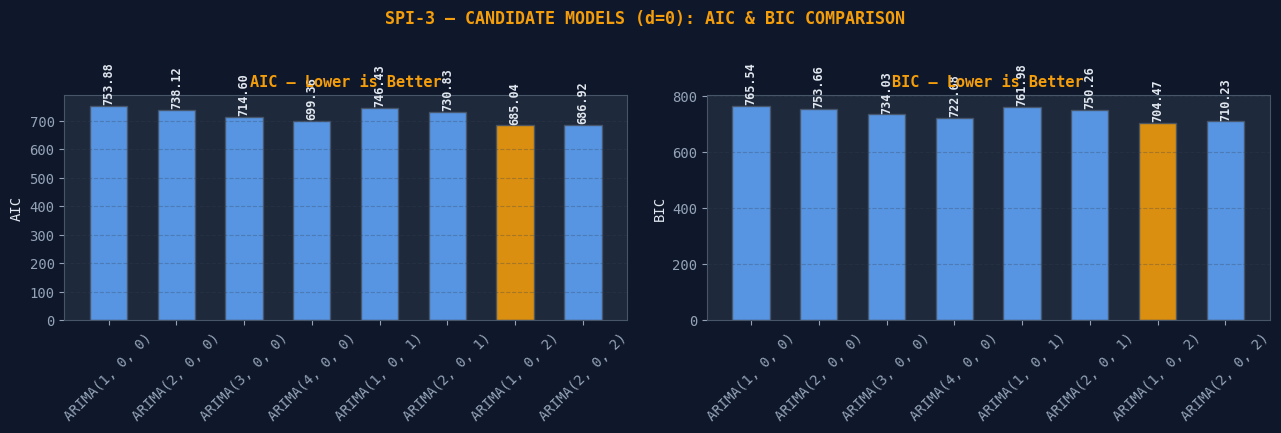

  ✓ Saved: 05_spi3_model_comparison.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — SPI-3 CANDIDATE MODELS: FIT & COMPARE (AIC / BIC)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 4: SPI-3 CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON")
print("=" * 70)

# d = 0 (NO differencing)
candidate_orders = [
    (1,0,0), (2,0,0), (3,0,0), (4,0,0),   # AR(1–4)
    (1,0,1), (2,0,1),                     # ARMA with q=1
    (1,0,2), (2,0,2)                      # ARMA with q=2
]

model_results = {}

print(f"\n  {'Model':<14} {'AIC':>10} {'BIC':>10} {'HQIC':>10} {'LogLik':>10} {'σ²':>12}")
print("  " + "-" * 62)

for order in candidate_orders:
    mod = ARIMA(train, order=order).fit()
    model_results[order] = mod
    sig2 = np.var(mod.resid)
    print(f"  ARIMA{str(order):<9} {mod.aic:>10.3f} {mod.bic:>10.3f} "
          f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>12.4f}")

# Best by AIC
best_order = min(model_results, key=lambda o: model_results[o].aic)
print(f"\n  Best model by AIC: ARIMA{best_order}")

# ── Plot AIC/BIC comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle('SPI-3 — CANDIDATE MODELS (d=0): AIC & BIC COMPARISON',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

labels   = [f'ARIMA{o}' for o in candidate_orders]
aic_vals = [model_results[o].aic for o in candidate_orders]
bic_vals = [model_results[o].bic for o in candidate_orders]

colors = [AMBER if o == best_order else BLUE for o in candidate_orders]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'),
                         (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(labels, vals, color=colors, edgecolor='#475569',
                  width=0.55, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.05*(max(vals)-min(vals)),
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5,
                color='#e2e8f0', fontweight='bold', rotation=90)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('05_spi3_model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 05_spi3_model_comparison.png")

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — ARIMA(1,0,2): COEFFICIENTS & FULL EQUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 5: ARIMA(1,0,2) — ESTIMATED COEFFICIENTS & EQUATION")
print("=" * 70)

final_model = model_results[(1,0,2)]
params      = final_model.params
sigma2      = np.var(final_model.resid)

# Robust parameter extraction (statsmodels may include 'const')
pnames = list(final_model.param_names)
pmap   = dict(zip(pnames, params))

c      = pmap.get('const', 0.0)
phi1   = pmap.get('ar.L1', np.nan)
th1    = pmap.get('ma.L1', np.nan)
th2    = pmap.get('ma.L2', np.nan)

print(f"\n  ── Estimated Coefficients ──────────────────────────────────────")
if 'const' in pmap:
    print(f"    c (const) = {c:+.6f}")
print(f"    φ₁ (ar.L1) = {phi1:+.6f}")
print(f"    θ₁ (ma.L1) = {th1:+.6f}")
print(f"    θ₂ (ma.L2) = {th2:+.6f}")
print(f"    σ²         = {sigma2:.6f}")

# Long-run mean if stationary
mu = np.nan
if np.isfinite(phi1) and abs(phi1) < 1:
    mu = c / (1 - phi1)

print(f"""
  ── FULL EQUATION DERIVATION ─────────────────────────────────────────

  General ARIMA(p,d,q) in backshift notation:
    φ(B) (1−B)^d Yₜ = c + θ(B) εₜ

  For ARIMA(1,0,2): p=1, d=0, q=2
    φ(B) = (1 − φ₁B)
    θ(B) = (1 + θ₁B + θ₂B²)

  Step 1 — Write the backshift form:
    (1 − φ₁B) Yₜ = c + (1 + θ₁B + θ₂B²) εₜ

  Step 2 — Expand the operators (B Yₜ = Yₜ₋₁, B εₜ = εₜ₋₁):
    Yₜ − φ₁Yₜ₋₁ = c + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂

  Step 3 — Rearrange (time-domain ARMA form):
    Yₜ = c + φ₁Yₜ₋₁ + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂

  ── FINAL EQUATION WITH ESTIMATED PARAMETERS ─────────────────────────

    Yₜ = {c:+.4f} + ({phi1:+.4f})·Yₜ₋₁ + εₜ + ({th1:+.4f})·εₜ₋₁ + ({th2:+.4f})·εₜ₋₂

  ── MEAN FORM (if |φ₁| < 1) ──────────────────────────────────────────
""")

if np.isfinite(mu):
    print(f"    μ = c/(1−φ₁) = {mu:+.4f}")
    print(f"""
    Yₜ − μ = φ₁ (Yₜ₋₁ − μ) + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂
""")
else:
    print("    (Mean form not shown because φ₁ is not in (-1,1) or was not found.)\n")

print(f"""
  ── ONE-STEP AHEAD FORECAST (conditional mean) ──────────────────────

  Using εₜ = 0 in expectation for forecast, but keeping past residuals:

    Ŷₜ|ₜ₋₁ = {c:+.4f} + ({phi1:+.4f})·Yₜ₋₁ + ({th1:+.4f})·êₜ₋₁ + ({th2:+.4f})·êₜ₋₂

  Residual update:
    êₜ = Yₜ − Ŷₜ|ₜ₋₁
""")


  SECTION 5: ARIMA(1,0,2) — ESTIMATED COEFFICIENTS & EQUATION

  ── Estimated Coefficients ──────────────────────────────────────
    c (const) = +0.111255
    φ₁ (ar.L1) = +0.147530
    θ₁ (ma.L1) = +0.744776
    θ₂ (ma.L2) = +0.632790
    σ²         = 0.380484

  ── FULL EQUATION DERIVATION ─────────────────────────────────────────

  General ARIMA(p,d,q) in backshift notation:
    φ(B) (1−B)^d Yₜ = c + θ(B) εₜ

  For ARIMA(1,0,2): p=1, d=0, q=2
    φ(B) = (1 − φ₁B)
    θ(B) = (1 + θ₁B + θ₂B²)

  Step 1 — Write the backshift form:
    (1 − φ₁B) Yₜ = c + (1 + θ₁B + θ₂B²) εₜ

  Step 2 — Expand the operators (B Yₜ = Yₜ₋₁, B εₜ = εₜ₋₁):
    Yₜ − φ₁Yₜ₋₁ = c + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂

  Step 3 — Rearrange (time-domain ARMA form):
    Yₜ = c + φ₁Yₜ₋₁ + εₜ + θ₁εₜ₋₁ + θ₂εₜ₋₂

  ── FINAL EQUATION WITH ESTIMATED PARAMETERS ─────────────────────────

    Yₜ = +0.1113 + (+0.1475)·Yₜ₋₁ + εₜ + (+0.7448)·εₜ₋₁ + (+0.6328)·εₜ₋₂

  ── MEAN FORM (if |φ₁| < 1) ──────────────────────────────────────────

  

Let's go to the prediction.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — ONE-STEP-AHEAD FORECASTING (2010–2018) | ARIMA(1,0,2)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 6: ONE-STEP-AHEAD FORECASTING (2010–2018) — ARIMA(1,0,2)")
print("  (Each forecast uses observed lags; errors do NOT compound)")
print("=" * 70)

print("""
  ── Strategy: Rolling One-Step-Ahead ────────────────────────────────
  For each month t in the TEST period:
    1) Fit ARIMA(1,0,2) using data up to t-1
    2) Forecast Y_t (1-step ahead)
    3) Append the ACTUAL observed Y_t to the history
  This mimics real-time forecasting and avoids error accumulation.
""")

best_order  = (1,0,2)

# Rolling history starts with training data
history = train.copy()

pred_list  = []
obs_list   = []
date_list  = []
err_list   = []

# Rolling 1-step forecasts through full test set (2010–2018)
for dt, y_obs in test.items():
    fit = ARIMA(history, order=best_order).fit()
    y_hat = float(fit.forecast(steps=1).iloc[0])

    pred_list.append(y_hat)
    obs_list.append(float(y_obs))
    date_list.append(dt)

    err_list.append(float(y_obs) - y_hat)

    # Update history with ACTUAL observation
    history = pd.concat([history, pd.Series([y_obs], index=[dt])])

df_fc = pd.DataFrame({
    "Date": date_list,
    "Y_obs": obs_list,
    "Y_hat": pred_list,
})
df_fc["Error"] = df_fc["Y_obs"] - df_fc["Y_hat"]
df_fc["AbsErr"] = np.abs(df_fc["Error"])

# Safer MAPE for SPI (SPI can be near zero)
# We'll report sMAPE instead of MAPE (more stable around zero).
df_fc["sMAPE"] = 200 * df_fc["AbsErr"] / (np.abs(df_fc["Y_obs"]) + np.abs(df_fc["Y_hat"]) + 1e-8)

rmse  = np.sqrt(np.mean(df_fc["Error"]**2))
mae   = np.mean(df_fc["AbsErr"])
smape = np.mean(df_fc["sMAPE"])
bias  = np.mean(df_fc["Error"])

print(f"\n  ── One-Step-Ahead Accuracy Metrics (2010–2018) ────────────────")
print(f"    RMSE   = {rmse:.4f}")
print(f"    MAE    = {mae:.4f}")
print(f"    sMAPE  = {smape:.2f}%")
print(f"    Bias   = {bias:.4f}  {'(over-forecast)' if bias < 0 else '(under-forecast)'}")

# Preview 2010-01 to 2011-12 table
mask_2010_2011 = (df_fc["Date"] >= "2010-01-01") & (df_fc["Date"] <= "2011-12-01")
df_zoom = df_fc.loc[mask_2010_2011].copy()

print("\n  ── Forecast table (2010-01 to 2011-12) ─────────────────────────")
print(df_zoom.head(6).to_string(index=False))
print("  ...")
print(df_zoom.tail(6).to_string(index=False))


  SECTION 6: ONE-STEP-AHEAD FORECASTING (2010–2018) — ARIMA(1,0,2)
  (Each forecast uses observed lags; errors do NOT compound)

  ── Strategy: Rolling One-Step-Ahead ────────────────────────────────
  For each month t in the TEST period:
    1) Fit ARIMA(1,0,2) using data up to t-1
    2) Forecast Y_t (1-step ahead)
    3) Append the ACTUAL observed Y_t to the history
  This mimics real-time forecasting and avoids error accumulation.


  ── One-Step-Ahead Accuracy Metrics (2010–2018) ────────────────
    RMSE   = 0.6512
    MAE    = 0.5079
    sMAPE  = 85.36%
    Bias   = -0.0483  (over-forecast)

  ── Forecast table (2010-01 to 2011-12) ─────────────────────────
      Date  Y_obs    Y_hat    Error   AbsErr      sMAPE
2010-01-01   0.32 0.129718 0.190282 0.190282  84.622808
2010-02-01   1.68 0.467381 1.212619 1.212619 112.939352
2010-03-01   1.87 1.372394 0.497606 0.497606  30.693724
2010-04-01   1.70 1.524978 0.175022 0.175022  10.854152
2010-05-01   0.89 0.811679 0.078321 0.078321  


  SECTION 7: OBSERVED vs ONE-STEP-AHEAD FORECAST — PLOTS


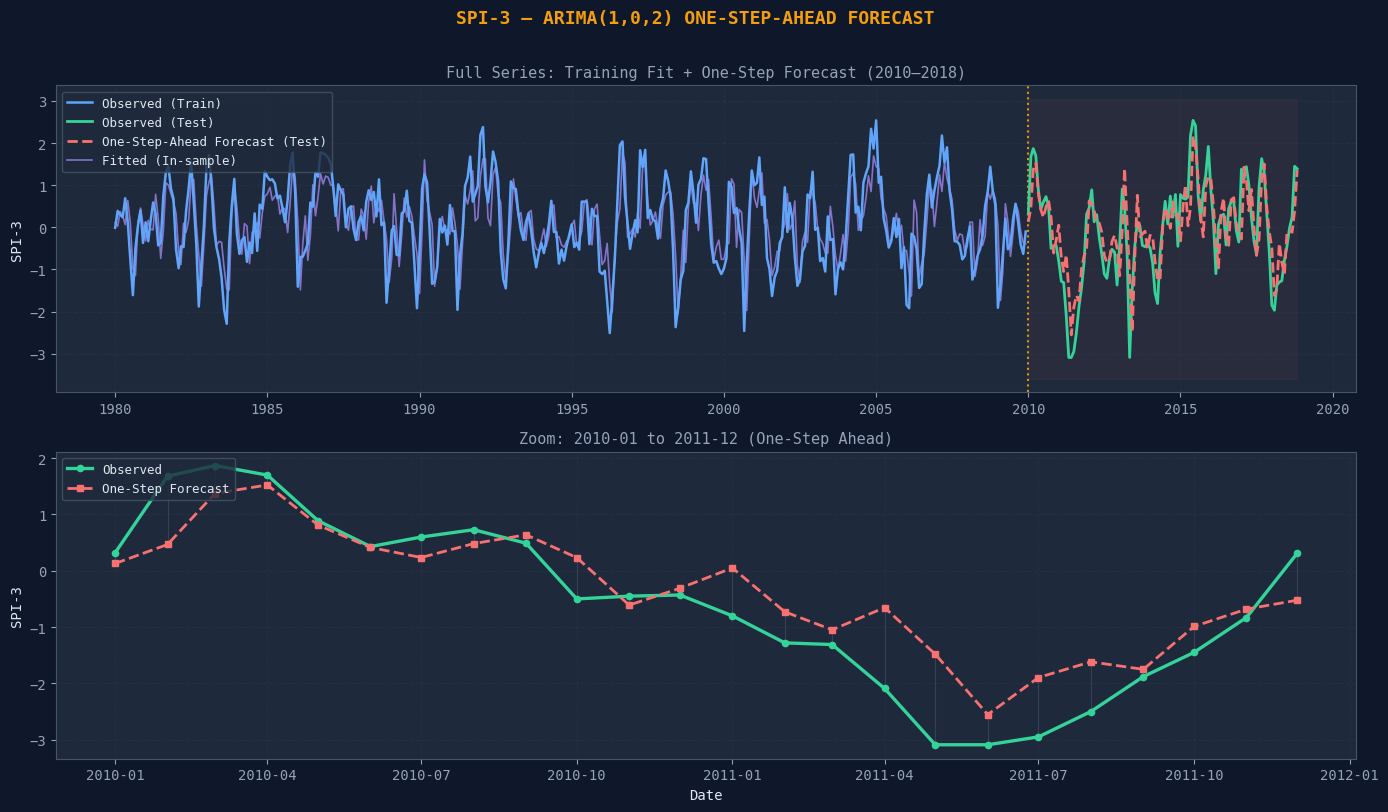

  ✓ Saved: 06_spi3_one_step_forecast.png


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — OBSERVED vs ONE-STEP-AHEAD FORECAST PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 7: OBSERVED vs ONE-STEP-AHEAD FORECAST — PLOTS")
print("=" * 70)

# 1) In-sample fitted values on training (single fit)
final_fit = ARIMA(train, order=best_order).fit()
fitted_train = final_fit.fittedvalues

# Combine series for plotting
full_obs = pd.concat([train, test]).sort_index()
full_hat = pd.Series(df_fc["Y_hat"].values, index=pd.to_datetime(df_fc["Date"]))

split_date = test.index.min()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('SPI-3 — ARIMA(1,0,2) ONE-STEP-AHEAD FORECAST',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)

# ── Top panel: full period ────────────────────────────────────────────────
ax = axes[0]
ax.plot(train.index, train.values, color=BLUE, lw=1.8,
        label='Observed (Train)', zorder=3)
ax.plot(test.index, test.values, color=GREEN, lw=2.0,
        label='Observed (Test)', zorder=3)

# Forecasts (test only)
ax.plot(full_hat.index, full_hat.values, color=ROSE, lw=2.0, ls='--',
        label='One-Step-Ahead Forecast (Test)', zorder=4)

# In-sample fit (train)
ax.plot(fitted_train.index, fitted_train.values, color=PURPLE, lw=1.2, alpha=0.75,
        label='Fitted (In-sample)', zorder=2)

# Split marker + shading
ax.axvline(split_date, color=AMBER, lw=1.5, ls=':', alpha=0.9)
ymin = full_obs.min() - 0.5
ymax = full_obs.max() + 0.5
ax.fill_betweenx([ymin, ymax], split_date, full_obs.index.max(),
                 alpha=0.05, color=ROSE)

ax.set_ylabel('SPI-3')
ax.set_title('Full Series: Training Fit + One-Step Forecast (2010–2018)', color=SLATE)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

# ── Bottom panel: zoom Jan 2010 to Dec 2011 ───────────────────────────────
ax2 = axes[1]
zoom_start = pd.to_datetime("2010-01-01")
zoom_end   = pd.to_datetime("2011-12-01")

obs_zoom = full_obs.loc[zoom_start:zoom_end]
hat_zoom = full_hat.loc[zoom_start:zoom_end]

ax2.plot(obs_zoom.index, obs_zoom.values, color=GREEN, lw=2.4, marker='o', ms=4.5,
         label='Observed', zorder=3)
ax2.plot(hat_zoom.index, hat_zoom.values, color=ROSE, lw=2.0, marker='s', ms=4,
         ls='--', label='One-Step Forecast', zorder=4)

# Vertical connectors (nice teaching visual)
for dt in obs_zoom.index:
    if dt in hat_zoom.index:
        ax2.vlines(dt, min(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   max(obs_zoom.loc[dt], hat_zoom.loc[dt]),
                   color='#475569', lw=0.8, alpha=0.55)

ax2.set_xlabel('Date')
ax2.set_ylabel('SPI-3')
ax2.set_title('Zoom: 2010-01 to 2011-12 (One-Step Ahead)', color=SLATE)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_spi3_one_step_forecast.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()

print("  ✓ Saved: 06_spi3_one_step_forecast.png")


  SECTION 8: COMPLETE FORECAST TABLE (2010–2018) — ARIMA(1,0,2)

        Date   Ŷₜ (Forecast)    Yₜ (Obs)       Error      AbsErr      sMAPE%
  ────────────────────────────────────────────────────────────────────────
     2010-01          0.1297      0.3200      0.1903      0.1903      84.62%
     2010-02          0.4674      1.6800      1.2126      1.2126     112.94%
     2010-03          1.3724      1.8700      0.4976      0.4976      30.69%
     2010-04          1.5250      1.7000      0.1750      0.1750      10.85%
     2010-05          0.8117      0.8900      0.0783      0.0783       9.21%
     2010-06          0.4147      0.4300      0.0153      0.0153       3.63%
     2010-07          0.2359      0.6000      0.3641      0.3641      87.13%
     2010-08          0.4829      0.7300      0.2471      0.2471      40.74%
     2010-09          0.6393      0.4900     -0.1493      0.1493      26.44%
     2010-10          0.2337     -0.5000     -0.7337      0.7337     200.00%
     2010-11

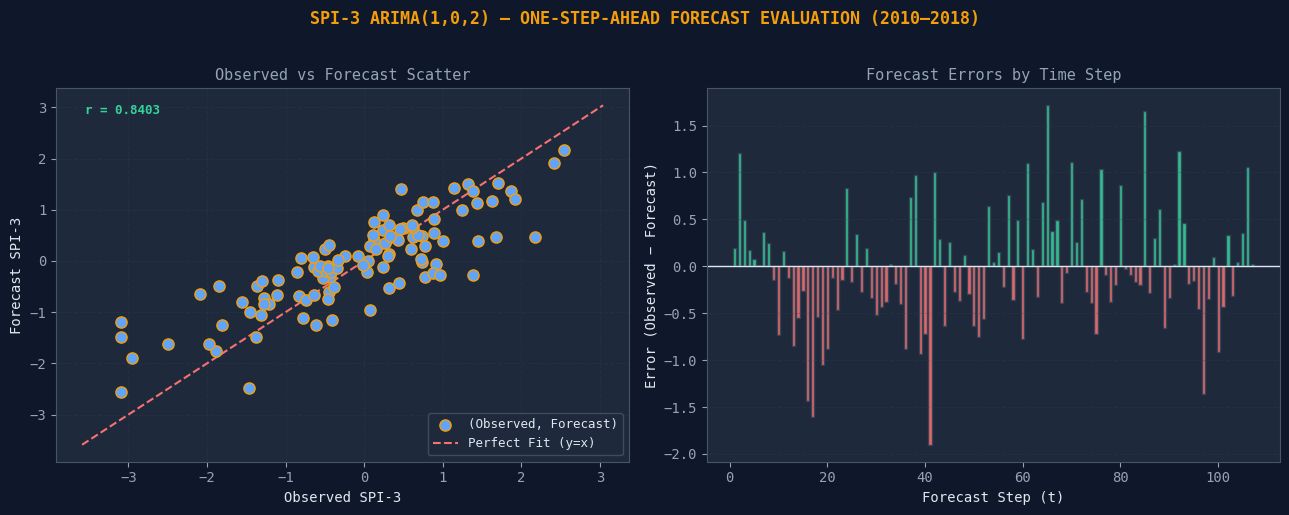

  ✓ Saved: 07_spi3_forecast_evaluation_one_step.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — FORECAST TABLE (2010–2018) + EVALUATION PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 8: COMPLETE FORECAST TABLE (2010–2018) — ARIMA(1,0,2)")
print("=" * 70)

# Ensure datetime
df_fc["Date"] = pd.to_datetime(df_fc["Date"])
df_fc = df_fc.sort_values("Date").reset_index(drop=True)

# Create an index-like counter (t) for printing and bar plot
df_fc["t"] = np.arange(1, len(df_fc) + 1)

# Metrics (SPI crosses zero => prefer sMAPE over MAPE)
rmse  = np.sqrt(np.mean(df_fc["Error"]**2))
mae   = np.mean(np.abs(df_fc["Error"]))
smape = np.mean(df_fc["sMAPE"])
bias  = np.mean(df_fc["Error"])

print(f"\n  {'Date':>10}  {'Ŷₜ (Forecast)':>14}  {'Yₜ (Obs)':>10}  {'Error':>10}  {'AbsErr':>10}  {'sMAPE%':>10}")
print("  " + "─" * 72)

for _, row in df_fc.iterrows():
    print(f"  {row.Date.strftime('%Y-%m'):>10}  {row.Y_hat:>14.4f}  {row.Y_obs:>10.4f}  "
          f"{row.Error:>10.4f}  {abs(row.Error):>10.4f}  {row.sMAPE:>9.2f}%")

print(f"\n  Metrics (2010–2018):  RMSE={rmse:.4f}   MAE={mae:.4f}   sMAPE={smape:.2f}%   Bias={bias:.4f}")

# ── Evaluation Plots: Scatter + Errors by time ───────────────────────────────
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SPI-3 ARIMA(1,0,2) — ONE-STEP-AHEAD FORECAST EVALUATION (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

# Scatter: Observed vs Forecast
ax = axes[0]
obs  = df_fc["Y_obs"].values
pred = df_fc["Y_hat"].values

ax.scatter(obs, pred, color=BLUE, edgecolors=AMBER, s=65, zorder=3,
           label='(Observed, Forecast)')
lims = [min(obs.min(), pred.min()) - 0.5, max(obs.max(), pred.max()) + 0.5]
ax.plot(lims, lims, color=ROSE, lw=1.5, ls='--', label='Perfect Fit (y=x)')

ax.set_xlabel('Observed SPI-3')
ax.set_ylabel('Forecast SPI-3')
ax.set_title('Observed vs Forecast Scatter', color=SLATE)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

r, p = stats.pearsonr(obs, pred)
ax.text(0.05, 0.93, f'r = {r:.4f}', transform=ax.transAxes,
        color=GREEN, fontsize=9, fontweight='bold')


ax2 = axes[1]
errors = df_fc["Error"].values
colors_bar = [GREEN if e >= 0 else ROSE for e in errors]

ax2.bar(df_fc["t"], errors, color=colors_bar, edgecolor='#334155',
        width=0.65, alpha=0.88)
ax2.axhline(0, color='#e2e8f0', lw=1)

ax2.set_xlabel('Forecast Step (t)')
ax2.set_ylabel('Error (Observed − Forecast)')
ax2.set_title('Forecast Errors by Time Step', color=SLATE)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('07_spi3_forecast_evaluation_one_step.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 07_spi3_forecast_evaluation_one_step.png")


  SECTION 9: DIAGNOSTIC PLOTS — RESIDUAL ANALYSIS (Training Fit)


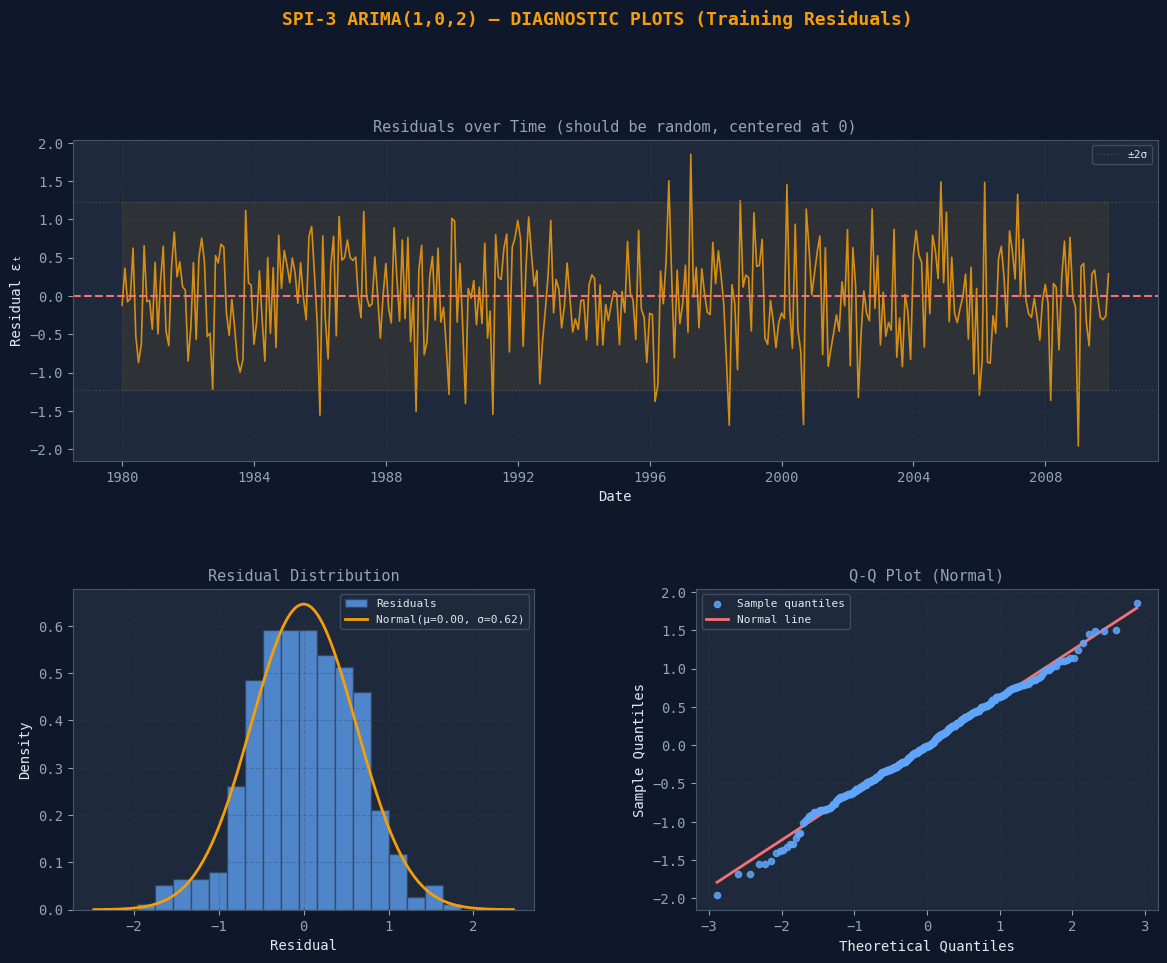

  ✓ Saved: 08_spi3_diagnostics.png


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — DIAGNOSTIC PLOTS (Residuals) — ARIMA(1,0,2)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 9: DIAGNOSTIC PLOTS — RESIDUAL ANALYSIS (Training Fit)")
print("=" * 70)

import matplotlib.gridspec as gridspec
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

final_fit = ARIMA(train, order=(1,0,2)).fit()
residuals = final_fit.resid.dropna()

fig = plt.figure(figsize=(14, 10))
fig.suptitle('SPI-3 ARIMA(1,0,2) — DIAGNOSTIC PLOTS (Training Residuals)',
             fontsize=13, color=AMBER, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# 1) Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals.index, residuals.values, color=AMBER, lw=1.2, alpha=0.85)
ax1.axhline(0, color=ROSE, lw=1.5, ls='--')
sig = np.std(residuals.values)
ax1.axhline(+2*sig, color='#475569', lw=1, ls=':', alpha=0.7, label='±2σ')
ax1.axhline(-2*sig, color='#475569', lw=1, ls=':', alpha=0.7)
ax1.fill_between(residuals.index, -2*sig, 2*sig, alpha=0.08, color=AMBER)
ax1.set_xlabel('Date')
ax1.set_ylabel('Residual εₜ')
ax1.set_title('Residuals over Time (should be random, centered at 0)', color=SLATE)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2) Histogram + normal overlay
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals.values, bins=18, color=BLUE, edgecolor='#334155',
         alpha=0.75, density=True, label='Residuals')
mu, std = residuals.mean(), residuals.std()
xr = np.linspace(mu - 4*std, mu + 4*std, 200)
ax2.plot(xr, stats.norm.pdf(xr, mu, std), color=AMBER, lw=2,
         label=f'Normal(μ={mu:.2f}, σ={std:.2f})')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Density')
ax2.set_title('Residual Distribution', color=SLATE)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3) Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, rqq) = stats.probplot(residuals.values, dist='norm')
ax3.scatter(osm, osr, color=BLUE, s=20, alpha=0.85, zorder=3, label='Sample quantiles')
ax3.plot(osm, slope*np.array(osm)+intercept, color=ROSE, lw=2, label='Normal line')
ax3.set_xlabel('Theoretical Quantiles')
ax3.set_ylabel('Sample Quantiles')
ax3.set_title('Q-Q Plot (Normal)', color=SLATE)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.savefig('08_spi3_diagnostics.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 08_spi3_diagnostics.png")
